# **Loan Prediction Model**

## **Goal:** Predict whether a loan application should be approved or rejected.

## Import the libraries

In [46]:
# import libraries

import os     # os for file system navigation and management
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn: pipeline and preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

# sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# sklearn model selection & evaluation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# model saving
import pickle

## Load & Understand the data

In [23]:
DATA_PATH = '/content/loan.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [24]:
print(f"Data shape: {df.shape}")
print(f"\nColumn names:\n {df.columns.tolist()}")

Data shape: (614, 13)

Column names:
 ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [25]:
# data summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [26]:
# statistical summary
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## EDA

In [27]:
# missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'missing count': missing, 'missing %': missing_pct}).query('`missing count` > 0')

,missing count,missing %
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130
Credit_History,50,8.143322


Loan_Status
Y    422
N    192
Name: count, dtype: int64

 Approval Rate: 68.7%


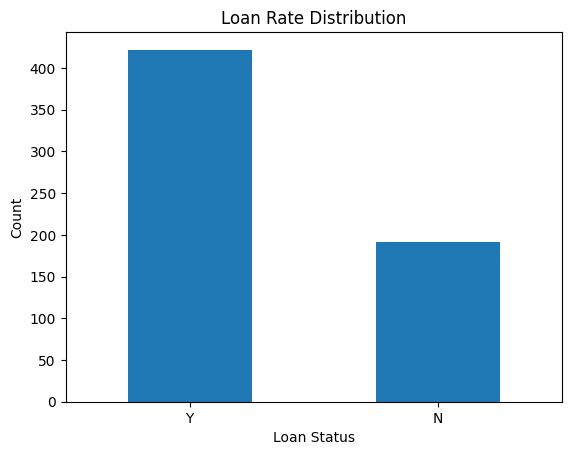

In [28]:
# distribution of target variable: Loan Status
print(df['Loan_Status'].value_counts())
print(f"\n Approval Rate: {(df['Loan_Status'] == 'Y').mean():.1%}")

# visualise class balance
df['Loan_Status'].value_counts().plot(kind = 'bar')
plt.title('Loan Rate Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation = 0) # displays labels horizontally
plt.show()

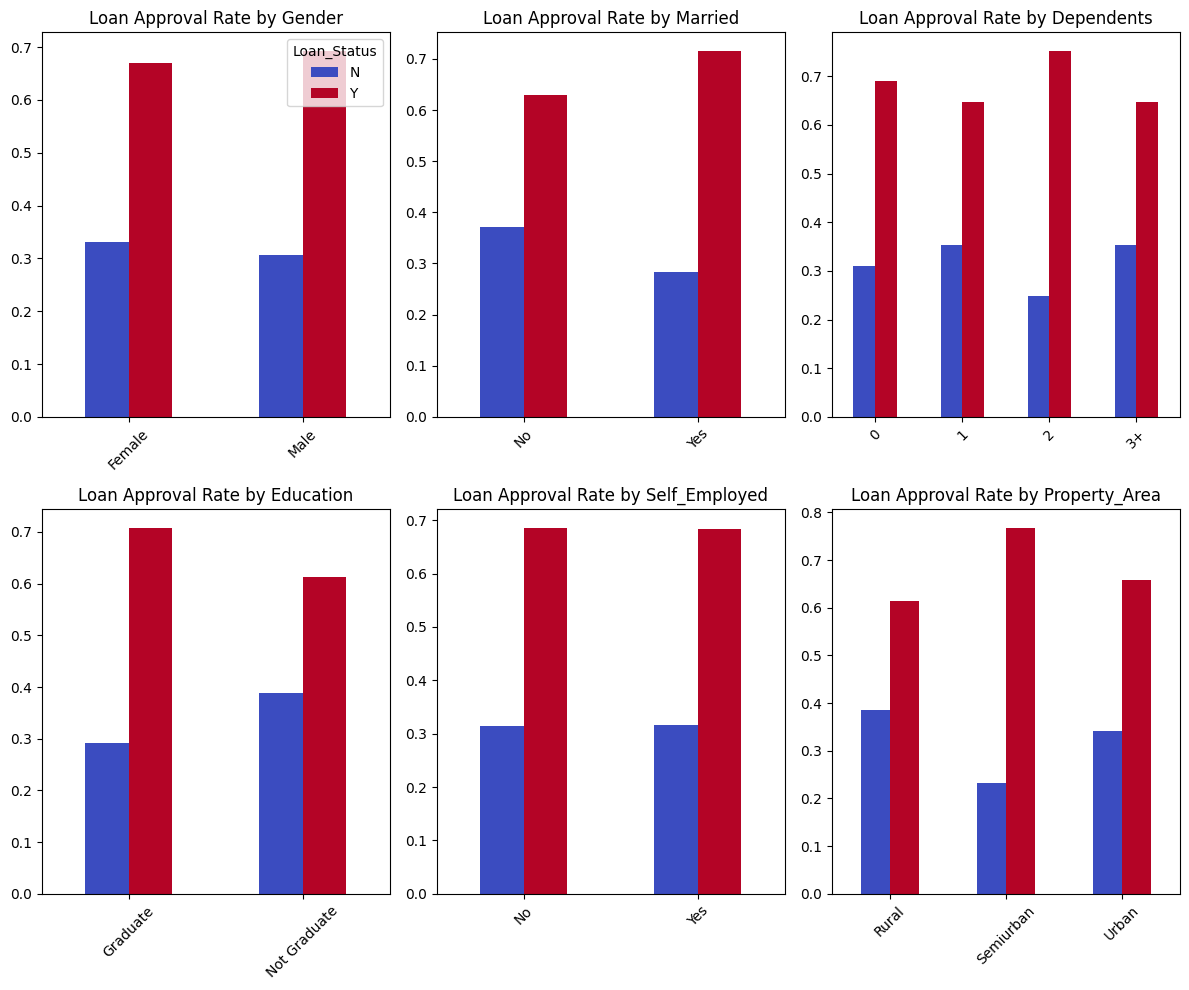

In [29]:
# loan approval rate accross categorical features
fig, axes = plt.subplots(2, 3, figsize = (12, 10))
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
for i, col in enumerate(cat_cols):
  ax = axes[i // 3, i % 3]
  df.groupby(col)['Loan_Status'].value_counts(normalize = True).unstack().plot(
      kind = 'bar', ax = ax, colormap = 'coolwarm', legend = (i == 0))
  ax.set_title(f'Loan Approval Rate by {col}')
  ax.set_xlabel('')
  ax.tick_params(axis = 'x', rotation = 45)  # rotate x labels 45 degrees to avoid overlap
plt.tight_layout()
plt.show()

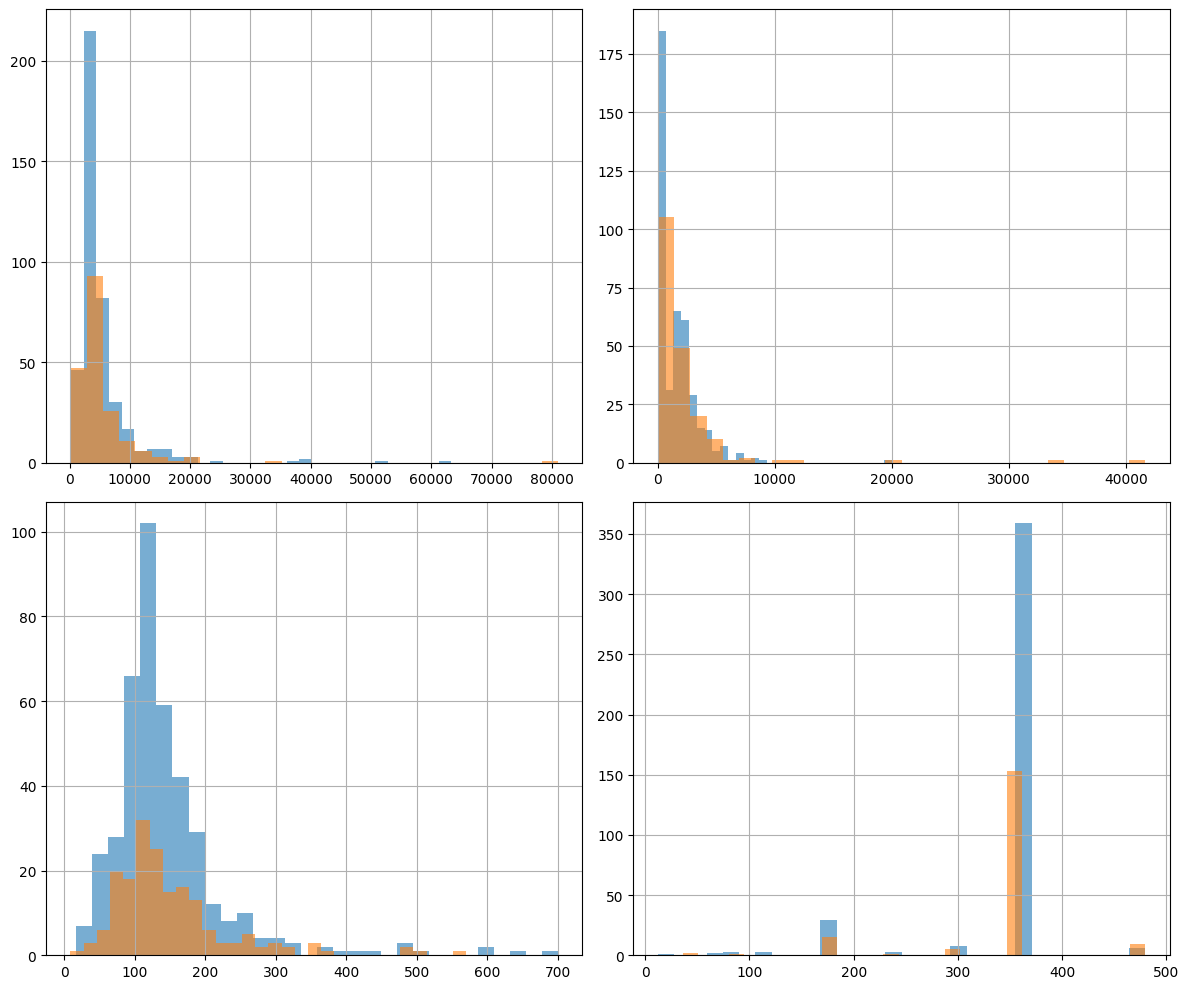

In [30]:
# loan approval rate across numerical features
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
axes = axes.flatten()

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
for i, col in enumerate(num_cols):
  for label in ['Y', 'N']:
    df[df['Loan_Status'] == label][col].hist(
        bins = 30, alpha = 0.6, ax = axes[i], label = label
        )
  ax.set_title(col)   # sets title to column name
  ax.legend()
# ax[-1].set_visible(False)
plt.tight_layout()
plt.show()

<Axes: >

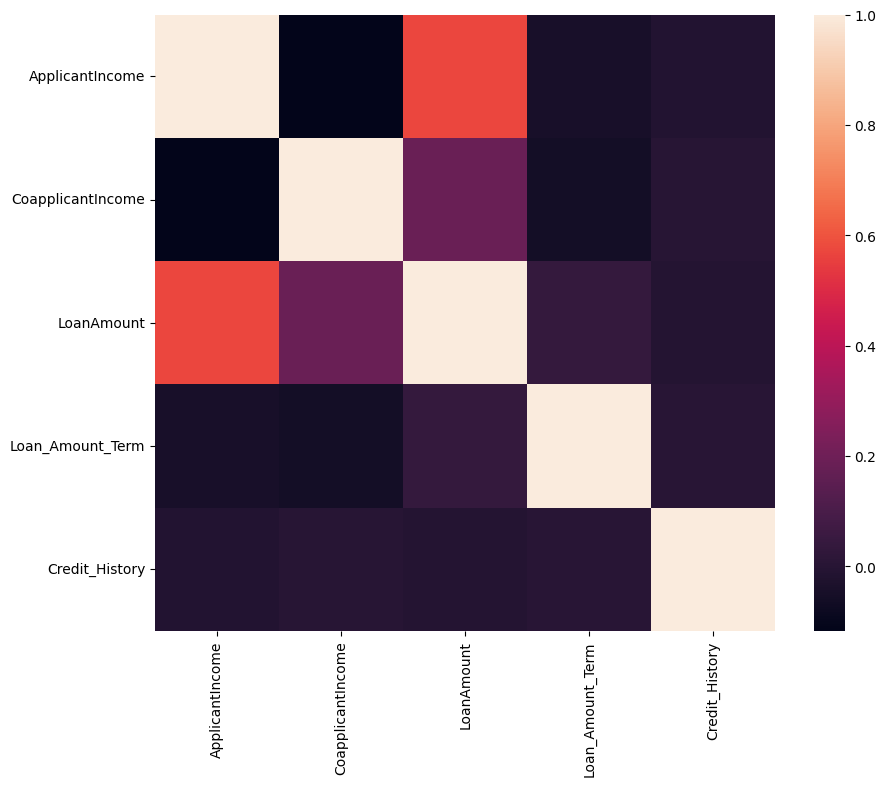

In [31]:
# correlation heatmap: numerical cols only
plt.figure(figsize = (10, 8))
num_cols = df.select_dtypes(include = np.number).columns
sns.heatmap(df[num_cols].corr())

## Feature Engineering

feature eng: total income, emi, balance income

In [32]:
# run all feature engineering on am independent copy of the dataframe, this keeps our base data intact
# copy of df
df_fe = df.copy()

In [33]:
# total income
df_fe['TotalIncome'] = df_fe['ApplicantIncome'] + df_fe['CoapplicantIncome']

# emi: estimated monthly income
df_fe['EMI'] = df_fe['LoanAmount'] / (df_fe['Loan_Amount_Term'] / 12)

# balance income: after emi deduction
df_fe['BalanceIncome'] = df_fe['TotalIncome'] - (df_fe['EMI'] * 1000)

In [34]:
# log transform for skewed distributions to reduce outlier impact
df_fe['Log_TotalIncome'] = np.log1p(df_fe['TotalIncome'])
df_fe['Log_LoanAmount'] = np.log1p(df_fe['LoanAmount'])

# drop engineered and redundant columns
df_fe.drop(['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount'], axis = 1, inplace = True)

In [35]:
print(f"Engineered df shape: {df_fe.shape}")
print(f"\nColumn names:\n {df_fe.columns.tolist()}")
df_fe.head()

Engineered df shape: (614, 14)

Column names:
 ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'TotalIncome', 'EMI', 'BalanceIncome', 'Log_TotalIncome', 'Log_LoanAmount']


,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,EMI,BalanceIncome,Log_TotalIncome,Log_LoanAmount
0,Male,No,0,Graduate,No,360.0,1.0,Urban,Y,5849.0,NaN,NaN,8.674197,NaN
1,Male,Yes,1,Graduate,No,360.0,1.0,Rural,N,6091.0,4.266667,1824.333333,8.714732,4.859812
2,Male,Yes,0,Graduate,Yes,360.0,1.0,Urban,Y,3000.0,2.200000,800.000000,8.006701,4.204693
3,Male,Yes,0,Not Graduate,No,360.0,1.0,Urban,Y,4941.0,4.000000,941.000000,8.505525,4.795791
4,Male,No,0,Graduate,No,360.0,1.0,Urban,Y,6000.0,4.700000,1300.000000,8.699681,4.955827


## Encode Target & Split data

In [36]:
# split features and target
X = df_fe.drop('Loan_Status', axis = 1)
y = df_fe['Loan_Status'].map({'Y': 1, 'N': 0})    # .map({'Y': 1, 'N': 0}) is used to encode the target

print(f"Features shape: {X.shape}")
print(f"Target distribution: {y.value_counts()}")

# identify feature types for model building
num_feat = X.select_dtypes(include = np.number).columns
cat_feat = X.select_dtypes(exclude = np.number).columns

print(f"\nNumerical features: {num_feat}")
print(f"\nCategorical features: {cat_feat}")

Features shape: (614, 13)
Target distribution: Loan_Status
1    422
0    192
Name: count, dtype: int64

Numerical features: Index(['Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'EMI',
       'BalanceIncome', 'Log_TotalIncome', 'Log_LoanAmount'],
      dtype='object')

Categorical features: Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')


In [37]:
# Stratified split — preserves class ratio in both train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

## Build the preprocessing pipeline

In [38]:
# pipeline to clean and handle missing data
# numeric pipeline: impute missing values -> scale
num_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

# categorical pipeline: impute missing values -> ordinal encode
cat_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1))
])

# combine into column transformer
preprocessor = ColumnTransformer(transformers = [
    ('num', num_pipeline, num_feat),
    ('cat', cat_pipeline, cat_feat)
], remainder = 'drop')

print("Preprocessing pipeline defined")

Preprocessing pipeline defined


## Train and compare multiple models

In [39]:
# Train multiple models with cross-validation: splits data into 5 fold while maintaining class distribution
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

models_to_compare = {
    'LogisticRegression': LogisticRegression(max_iter = 1000, random_state = 42),
    'RandomForest': RandomForestClassifier(n_estimators = 100, random_state = 42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators = 100, random_state = 42),
    'SVM': SVC(probability = True, random_state = 42)
}

# empty dict for model result, loop through each model & build pipeline
results = {}
for name, clf in models_to_compare.items():
  pipeline = Pipeline(steps = [
      ('preprocessor', preprocessor),
      ('classifier', clf)
  ])

  # cross validate the pipeline
  cv_scores = cross_val_score(pipeline, X_train, y_train, cv = cv, scoring = 'f1', n_jobs = -1)
  results[name] = {
      'mean_f1': cv_scores.mean(),
      'std_f1': cv_scores.std(),
      'scores': cv_scores
  }

  # display model results
  # {name:25s} pads the name to 25 characters so all results align neatly
  print(f"{name:25s} CV F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# best model
best_model_name = max(results, key = lambda k: results[k]['mean_f1'])
print(f"\n Best model: {best_model_name} (F1 = {results[best_model_name]['mean_f1']:.4f})")

LogisticRegression        CV F1 = 0.8699 ± 0.0272
RandomForest              CV F1 = 0.8441 ± 0.0296
GradientBoosting          CV F1 = 0.8462 ± 0.0246
SVM                       CV F1 = 0.8661 ± 0.0250

 Best model: LogisticRegression (F1 = 0.8699)


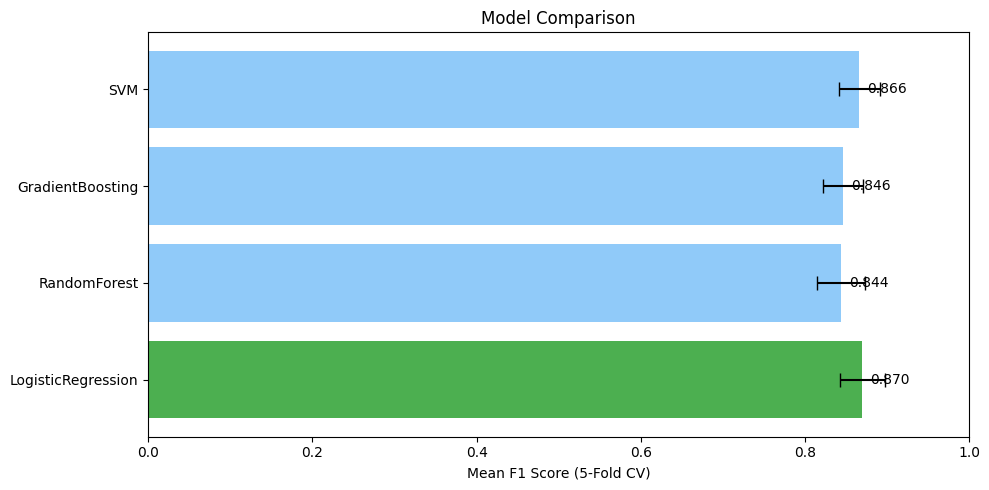

In [40]:
# visualise model comparison
fig, ax = plt.subplots(figsize = (10,5))
names = list(results.keys())

# extract data from results dictionary
means = [results[n]['mean_f1'] for n in names]
stds = [results[n]['std_f1'] for n in names]

# plot horizontal bars
bars = ax.barh(names, means, xerr=stds, capsize=5,
               color=['#4CAF50' if n == best_model_name else '#90CAF9' for n in names])

# style the axes
ax.set_xlabel('Mean F1 Score (5-Fold CV)')
ax.set_title('Model Comparison')
ax.set_xlim(0, 1)

# add score labels on each bar
for bar, mean in zip(bars, means):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning (best model)

In [41]:
# Hyperparameter Tuning for Best Model

# parameter grid
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],    # regularization strength
    'classifier__penalty': ['l1', 'l2', 'elasticnet'],  # regularization type
    'classifier__solver': ['saga'],                     # supports all penalties
    'classifier__class_weight': ['balanced', None],     # handles class imbalance
    'classifier__max_iter': [1000],                     # ensure convergence
}

# build the pipeline
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42)),
])

# configure GridsearcCV
grid_search = GridSearchCV(
    estimator = best_pipeline,    # full pipeline to tune
    param_grid = param_grid,      # all combinations to try
    cv = cv,                      # use the stratifiedkfold(5) defined earlier
    scoring = 'f1',               # pick the combination with the best f1 score
    n_jobs = 1,                   # use all cpu cores
    verbose = 1                   # print progress to show its running
)

# fit the grid search
grid_search.fit(X_train, y_train)

# print best results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

#retrieve final model: best_estimator returns the complete fitted pipeline with the best hyperparameters already applied
final_model  = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 1000, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best CV F1 Score: 0.8703


## Final Evaluation on Test set

In [44]:
# Final test
y_pred = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print('=' * 45)
print(f'Accuracy: {accuracy:.4f} ({accuracy:.1%})')
print(f'F1: {f1:.4f}')
print(f'Precission: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Roc Auc: {roc_auc:.4f}')

# print classification report
print(classification_report(y_test, y_pred, target_names = ['Rejected', 'Approved']))

Accuracy: 0.8537 (85.4%)
F1: 0.9032
Precission: 0.8317
Recall: 0.9882
Roc Auc: 0.7704
              precision    recall  f1-score   support

    Rejected       0.95      0.55      0.70        38
    Approved       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



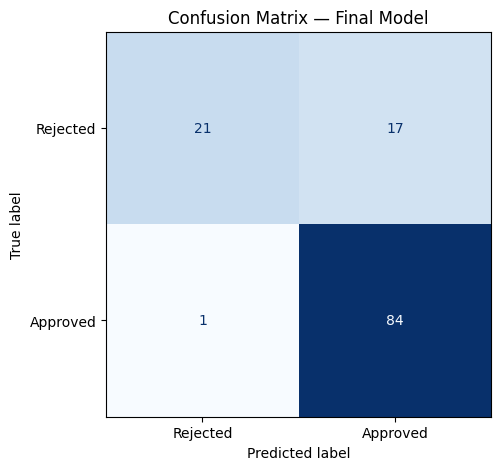

In [45]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Rejected', 'Approved'])
fig, ax = plt.subplots(figsize = (6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Final Model')
plt.show()

## Save Model

In [47]:
# Save Model Artifacts

MODEL_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH   = os.path.join(MODEL_DIR, 'loan_model.pkl')
COLUMNS_PATH = os.path.join(MODEL_DIR, 'loan_columns.pkl')
METRICS_PATH = os.path.join(MODEL_DIR, 'metrics.pkl')

# 1. Save the full pipeline (preprocessor + model)
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(final_model, f)

# 2. Save feature column names (backend uses this to build the input DataFrame)
with open(COLUMNS_PATH, 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

# 3. Save metrics for dashboard display
metrics = {
    'accuracy':  round(accuracy, 4),
    'f1_score':  round(f1, 4),
    'precision': round(precision, 4),
    'recall':    round(recall, 4),
    'roc_auc':   round(roc_auc, 4),
}
with open(METRICS_PATH, 'wb') as f:
    pickle.dump(metrics, f)

print(f"Model saved    → {MODEL_PATH}")
print(f"Columns saved  → {COLUMNS_PATH}")
print(f"Metrics saved  → {METRICS_PATH}")
print(f"\nFinal Model Metrics: {metrics}")


Model saved    → /content/../model/loan_model.pkl
Columns saved  → /content/../model/loan_columns.pkl
Metrics saved  → /content/../model/metrics.pkl

Final Model Metrics: {'accuracy': 0.8537, 'f1_score': 0.9032, 'precision': 0.8317, 'recall': 0.9882, 'roc_auc': np.float64(0.7704)}


## Smoke Test

In [48]:
# smoke test to verify backend adaptability

MODEL_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'model')

with open(os.path.join(MODEL_DIR, 'loan_model.pkl'), 'rb')   as f: loaded_model   = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'loan_columns.pkl'), 'rb') as f: loaded_columns = pickle.load(f)

# Simulate a backend request (same dict structure as LoanRequest schema)
sample_input = {
    'Gender':            1,     # Male
    'Married':           1,     # Yes
    'Dependents':        0,
    'Education':         0,     # Graduate
    'Self_Employed':     0,     # No
    'Loan_Amount_Term':  360.0,
    'Credit_History':    1.0,
    'Property_Area':     2,     # Semiurban

    # --- Engineered features (must match what was saved in X.columns) ---
    'TotalIncome':       8000,
    'EMI':               0.389,
    'BalanceIncome':    -389,
    'Log_TotalIncome':   8.988,
    'Log_LoanAmount':    5.075,
}

# Build input DataFrame with exact column order
input_df = pd.DataFrame([sample_input], columns=loaded_columns)

# Predict
result = loaded_model.predict(input_df)
label  = 'Approved ✅' if result[0] == 1 else 'Rejected ❌'
print(f"Smoke test prediction: {label}")
print("Backend compatibility confirmed!")


Smoke test prediction: Approved ✅
Backend compatibility confirmed!
